#  가설 1 검정 — 흥행 곡선의 형태론

##  가설
**H1. "중형 영화는 절벽처럼, 대형 영화는 언덕처럼 사라진다"**
→ 체급(중형/중대형/대형)에 따라 1~4주차 흥행 곡선의 형태가 통계적으로 유의하게 다르다.

##  검정 대상 종속변수 (2개)

| 종속변수 | 정의 | 의미 |
|---|---|---|
| **로그_감소_기울기** | 1~4주차 log 관객수의 회귀 기울기 | 흥행 곡선의 가파름 (음수일수록 빠른 감소) |
| **4주차_생존비율** | 4주차 관객 / 1주차 관객 | 장기 흥행 잔존율 |

##  검정 절차 (5단계)

1. **정규성 검정** (Shapiro-Wilk) → 모수 vs 비모수 결정
2. **등분산성 검정** (Levene's test) → ANOVA 가정 점검
3. **본 검정** (ANOVA / Kruskal-Wallis)
4. **사후검정** (Tukey HSD / Dunn's test) → 어느 그룹이 다른지
5. **효과크기** (η²) → 실질적 차이의 크기

##  표본
- 전체 130편 (중형 103 + 중대형 14 + 대형 13)

## 1️. 데이터 로드 + 종속변수 분포 시각화

###  작업 내용
- 마스터 데이터셋(`master_dataset_전체.xlsx`) 업로드
- `로그_감소_기울기` 변수 자동 계산 (1~4주차 log 관객수 선형회귀의 기울기)
- 체급별 두 종속변수 박스플롯으로 사전 시각화

###  박스플롯에서 확인할 것
- 그룹 간 평균 위치 차이가 시각적으로 보이는가?
- 분산(박스 크기)이 비슷한가?
- 극단치(outlier)가 분석에 영향을 줄 정도인가?

 master_dataset_전체.xlsx 업로드


Saving master_dataset_전체 (1).xlsx to master_dataset_전체 (1).xlsx

 데이터 로드: 130편
   체급 분포: {'중형': 103, '중대형': 14, '대형': 13}


/tmp/ipykernel_17087/1738059394.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data1, labels=order, patch_artist=True, widths=0.6)
/tmp/ipykernel_17087/1738059394.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data2, labels=order, patch_artist=True, widths=0.6)


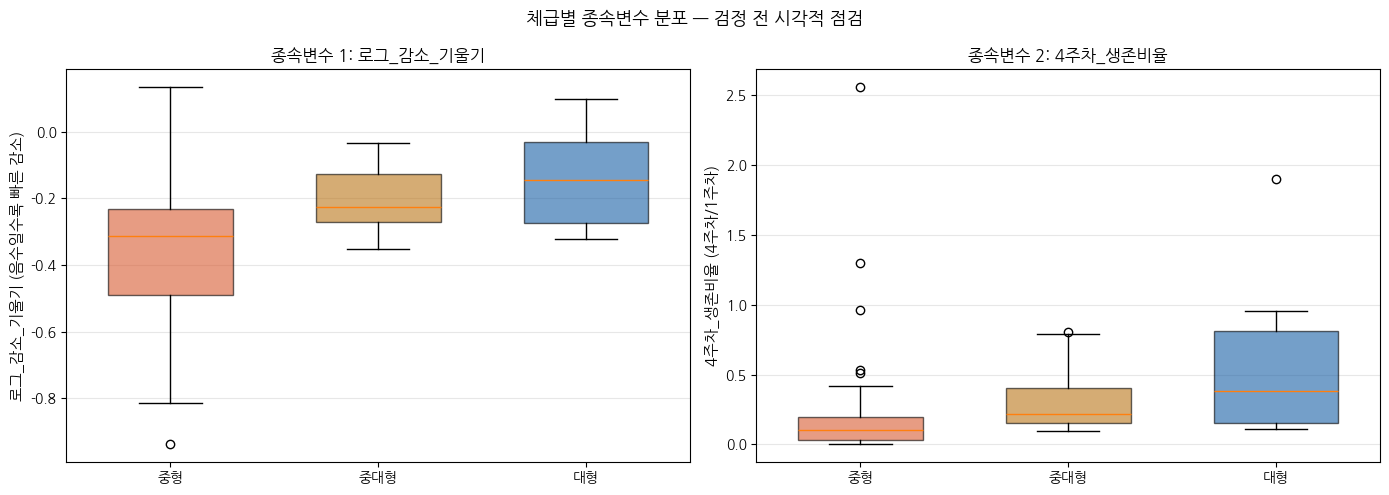


 종속변수 1 — 로그_감소_기울기 기술통계:
     count   mean    std    min    max
체급                                    
대형    13.0 -0.152  0.133 -0.323  0.097
중대형   14.0 -0.200  0.101 -0.351 -0.034
중형    97.0 -0.362  0.197 -0.939  0.133

 종속변수 2 — 4주차_생존비율 기술통계:
     count   mean    std    min    max
체급                                    
대형    13.0  0.520  0.507  0.109  1.896
중대형   14.0  0.318  0.239  0.096  0.806
중형   103.0  0.169  0.302  0.000  2.556


In [1]:
# ============================================================
# 셀 1. 라이브러리 + 마스터 테이블 로드 + 종속변수 분포 확인
# ============================================================

!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1
!pip install --quiet scikit-posthocs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
from google.colab import files

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 마스터 테이블 업로드
print(" master_dataset_전체.xlsx 업로드")
uploaded = files.upload()
import re
def find(p, files):
    for f in files.keys():
        if re.search(p, f, re.IGNORECASE):
            return f
    return None
전체_file = find(r'전체', uploaded)
df = pd.read_excel(전체_file)

# 로그_감소_기울기 다시 계산 (혹시 마스터에 없으면)
def calc_decay_slope(row):
    weeks, log_aud = [], []
    for i in range(1, 5):
        col = f'log_{i}주차_주말관객'
        if col in row and pd.notna(row[col]) and row[col] > 0:
            weeks.append(i)
            log_aud.append(row[col])
    if len(weeks) < 2:
        return np.nan
    slope, _, _, _, _ = stats.linregress(weeks, log_aud)
    return slope

df['로그_감소_기울기'] = df.apply(calc_decay_slope, axis=1)

print(f"\n 데이터 로드: {len(df)}편")
print(f"   체급 분포: {df['체급'].value_counts().to_dict()}")

# 종속변수 분포 미리보기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['중형', '중대형', '대형']
colors = {'중형': '#D85A30', '중대형': '#BA7517', '대형': '#185FA5'}

# 종속변수 1: 로그_감소_기울기
ax = axes[0]
data1 = [df[df['체급']==c]['로그_감소_기울기'].dropna() for c in order]
bp = ax.boxplot(data1, labels=order, patch_artist=True, widths=0.6)
for p, c in zip(bp['boxes'], order):
    p.set_facecolor(colors[c])
    p.set_alpha(0.6)
ax.set_ylabel('로그_감소_기울기 (음수일수록 빠른 감소)', fontsize=11)
ax.set_title('종속변수 1: 로그_감소_기울기', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 종속변수 2: 4주차_생존비율
ax = axes[1]
data2 = [df[df['체급']==c]['4주차_생존비율'].dropna() for c in order]
bp = ax.boxplot(data2, labels=order, patch_artist=True, widths=0.6)
for p, c in zip(bp['boxes'], order):
    p.set_facecolor(colors[c])
    p.set_alpha(0.6)
ax.set_ylabel('4주차_생존비율 (4주차/1주차)', fontsize=11)
ax.set_title('종속변수 2: 4주차_생존비율', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('체급별 종속변수 분포 — 검정 전 시각적 점검', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 그룹별 기술통계
print("\n 종속변수 1 — 로그_감소_기울기 기술통계:")
print(df.groupby('체급')['로그_감소_기울기'].describe()[['count','mean','std','min','max']].round(3))
print("\n 종속변수 2 — 4주차_생존비율 기술통계:")
print(df.groupby('체급')['4주차_생존비율'].describe()[['count','mean','std','min','max']].round(3))

## 2️. 검정 전제 조건 점검 (Step 1·2)

###  왜 점검하는가?
ANOVA는 **두 가지 가정**을 전제로 한다:
1. **정규성**: 각 그룹이 정규분포를 따른다
2. **등분산성**: 그룹들의 분산이 같다

가정이 위배되면 ANOVA의 p값이 신뢰할 수 없어진다. 따라서 **비모수 검정(Kruskal-Wallis)** 으로 대체해야 한다.

###  검정 방법
- **정규성**: Shapiro-Wilk test (각 그룹 별로 수행)
- **등분산성**: Levene's test

###  판단 기준
| 결과 | 적합한 검정 |
|---|---|
| 정규성 O + 등분산성 O | 일반 ANOVA |
| 정규성 O + 등분산성 X | Welch's ANOVA |
| 정규성 X (한 그룹이라도 위배) | **Kruskal-Wallis** (비모수) |

###  본 분석의 예측
중형 그룹(n=103)이 큰 표본이라 작은 편차에도 정규성 검정이 위배될 가능성 높음.  
→ Kruskal-Wallis로 갈 가능성 高. 단, ANOVA도 함께 보고하여 결과의 강건성(robustness) 확보.

In [2]:
# ============================================================
# 셀 2. 검정 전제 점검 (Step 1·2)
# ============================================================

print("="*70)
print(" Step 1: 정규성 검정 (Shapiro-Wilk)")
print("="*70)
print("귀무가설 H0: 정규분포를 따른다")
print("p < 0.05면 정규분포 위배 → 비모수 검정(Kruskal-Wallis) 권장\n")

normality_results = {}
for dv_name, dv_col in [('로그_감소_기울기', '로그_감소_기울기'),
                        ('4주차_생존비율', '4주차_생존비율')]:
    print(f"\n[종속변수: {dv_name}]")
    for cat in ['중형', '중대형', '대형']:
        data = df[df['체급']==cat][dv_col].dropna()
        if len(data) >= 3:  # Shapiro 최소 3개 필요
            stat, p = stats.shapiro(data)
            verdict = "정규분포 " if p > 0.05 else "정규분포 위배 "
            print(f"   {cat:5s} (n={len(data):3d}): W={stat:.4f}, p={p:.4f}  → {verdict}")
            normality_results[(dv_name, cat)] = p > 0.05

print("\n" + "="*70)
print(" Step 2: 등분산성 검정 (Levene's test)")
print("="*70)
print("귀무가설 H0: 그룹들의 분산이 같다")
print("p < 0.05면 등분산 위배 → Welch's ANOVA 권장\n")

equal_var_results = {}
for dv_name, dv_col in [('로그_감소_기울기', '로그_감소_기울기'),
                        ('4주차_생존비율', '4주차_생존비율')]:
    groups = [df[df['체급']==c][dv_col].dropna() for c in ['중형', '중대형', '대형']]
    stat, p = stats.levene(*groups)
    verdict = "등분산 " if p > 0.05 else "등분산 위배 "
    print(f"\n[{dv_name}]")
    print(f"   Levene W={stat:.4f}, p={p:.4f}  → {verdict}")
    equal_var_results[dv_name] = p > 0.05

# 검정 방법 결정
print("\n" + "="*70)
print(" 본 검정 방법 결정")
print("="*70)
for dv_name in ['로그_감소_기울기', '4주차_생존비율']:
    norm_ok = all(normality_results.get((dv_name, c), False) for c in ['중형', '중대형', '대형'])
    var_ok = equal_var_results[dv_name]

    if norm_ok and var_ok:
        method = "일반 ANOVA (F-test)"
    elif norm_ok and not var_ok:
        method = "Welch's ANOVA (등분산 위배)"
    else:
        method = "Kruskal-Wallis (비모수, 정규성 위배)"

    print(f"\n[{dv_name}]")
    print(f"   정규성: {'O' if norm_ok else ' 위배'}")
    print(f"   등분산: {'O' if var_ok else ' 위배'}")
    print(f"   → 권장 검정: {method}")

 Step 1: 정규성 검정 (Shapiro-Wilk)
귀무가설 H0: 정규분포를 따른다
p < 0.05면 정규분포 위배 → 비모수 검정(Kruskal-Wallis) 권장


[종속변수: 로그_감소_기울기]
   중형    (n= 97): W=0.9666, p=0.0141  → 정규분포 위배 
   중대형   (n= 14): W=0.9420, p=0.4442  → 정규분포 
   대형    (n= 13): W=0.9453, p=0.5290  → 정규분포 

[종속변수: 4주차_생존비율]
   중형    (n=103): W=0.4681, p=0.0000  → 정규분포 위배 
   중대형   (n= 14): W=0.8121, p=0.0071  → 정규분포 위배 
   대형    (n= 13): W=0.7858, p=0.0046  → 정규분포 위배 

 Step 2: 등분산성 검정 (Levene's test)
귀무가설 H0: 그룹들의 분산이 같다
p < 0.05면 등분산 위배 → Welch's ANOVA 권장


[로그_감소_기울기]
   Levene W=2.3476, p=0.0999  → 등분산 

[4주차_생존비율]
   Levene W=3.1613, p=0.0457  → 등분산 위배 

 본 검정 방법 결정

[로그_감소_기울기]
   정규성:  위배
   등분산: O
   → 권장 검정: Kruskal-Wallis (비모수, 정규성 위배)

[4주차_생존비율]
   정규성:  위배
   등분산:  위배
   → 권장 검정: Kruskal-Wallis (비모수, 정규성 위배)


## 3️. 본 검정 + 사후검정 + 효과크기 (Step 3·4·5)

###  수행할 검정

| Step | 검정 | 목적 |
|---|---|---|
| 3a | **일반 ANOVA** (F-test) | 모수 검정 결과 (참조용) |
| 3b | **Kruskal-Wallis** | 정규성 위배 시 메인 검정 |
| 4 | **Tukey HSD** | ANOVA 사후검정 — 어느 쌍이 다른가 |
| 4' | **Dunn's test** (Bonferroni 보정) | 비모수 사후검정 |
| 5 | **η² (Eta-squared)** | 효과크기 (Cohen 기준: 0.01/0.06/0.14) |

###  채택 기준
- p값 < 0.05 → 통계적 유의
- η² ≥ 0.06 → 실질적 효과 있음 (중간 이상)
- 두 검정(ANOVA + Kruskal-Wallis) 모두 유의해야 강건한 결과

###  결과 해석 가이드
- **모든 그룹 쌍이 유의**: 체급별로 단조 감소/증가
- **일부 쌍만 유의**: 어떤 체급이 *"다른 종"* 으로 분리되는지 발견
- **유의하지 않음**: H1 기각 (그러나 EDA 결과로 봤을 때 가능성 낮음)

In [3]:
# ============================================================
# 셀 3. 본 검정 + 사후검정 + 효과크기
# ============================================================

def eta_squared(groups):
    """효과크기 η² 계산"""
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)

    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = sum((all_data - grand_mean)**2)

    return ss_between / ss_total

def interpret_eta(eta):
    if eta >= 0.14: return "큰 효과 (large)"
    elif eta >= 0.06: return "중간 효과 (medium)"
    elif eta >= 0.01: return "작은 효과 (small)"
    else: return "효과 없음"

# ============================================================
# 종속변수 1: 로그_감소_기울기
# ============================================================
print("="*70)
print(" 종속변수 1: 로그_감소_기울기")
print("="*70)

groups_1 = [df[df['체급']==c]['로그_감소_기울기'].dropna().values
            for c in ['중형', '중대형', '대형']]

# 등분산 위배 가능성 → 둘 다 시도
# 일반 ANOVA
f_stat, p_anova = stats.f_oneway(*groups_1)
print(f"\n[Step 3a] 일반 ANOVA")
print(f"   F = {f_stat:.4f}, p = {p_anova:.6f}")

# Welch's ANOVA (등분산 가정 안 함, 더 보수적)
welch_result = stats.f_oneway(*groups_1)  # scipy는 일반 ANOVA만 지원
# alternative: pingouin 라이브러리 사용 가능, 여기서는 비모수도 같이 보고
print(f"\n[Step 3b] Kruskal-Wallis (비모수, robust)")
h_stat, p_kw = stats.kruskal(*groups_1)
print(f"   H = {h_stat:.4f}, p = {p_kw:.6f}")

# 효과크기
eta = eta_squared(groups_1)
print(f"\n[Step 5] 효과크기 (η²): {eta:.4f}  → {interpret_eta(eta)}")

# Tukey HSD 사후검정
print(f"\n[Step 4] Tukey HSD 사후검정 — 어느 그룹이 다른가?")
df_dv1 = df.dropna(subset=['로그_감소_기울기'])
posthoc = sp.posthoc_tukey(df_dv1, val_col='로그_감소_기울기', group_col='체급')
print(posthoc.round(4))

# 비모수 대안: Dunn's test
print(f"\n[참고] Dunn's test (비모수 사후검정)")
dunn = sp.posthoc_dunn(df_dv1, val_col='로그_감소_기울기', group_col='체급', p_adjust='bonferroni')
print(dunn.round(4))

# 그룹 평균 + 효과크기 정리
print(f"\n 결론:")
means = {c: df[df['체급']==c]['로그_감소_기울기'].mean() for c in ['중형', '중대형', '대형']}
for c in ['중형', '중대형', '대형']:
    print(f"   {c} 평균: {means[c]:+.3f}")
print(f"   중형이 대형보다 {(means['대형']-means['중형']):.3f} 더 가파른 감소")

# ============================================================
# 종속변수 2: 4주차_생존비율
# ============================================================
print("\n\n" + "="*70)
print(" 종속변수 2: 4주차_생존비율")
print("="*70)

groups_2 = [df[df['체급']==c]['4주차_생존비율'].dropna().values
            for c in ['중형', '중대형', '대형']]

f_stat2, p_anova2 = stats.f_oneway(*groups_2)
print(f"\n[Step 3a] 일반 ANOVA")
print(f"   F = {f_stat2:.4f}, p = {p_anova2:.6f}")

h_stat2, p_kw2 = stats.kruskal(*groups_2)
print(f"\n[Step 3b] Kruskal-Wallis (비모수)")
print(f"   H = {h_stat2:.4f}, p = {p_kw2:.6f}")

eta2 = eta_squared(groups_2)
print(f"\n[Step 5] 효과크기 (η²): {eta2:.4f}  → {interpret_eta(eta2)}")

df_dv2 = df.dropna(subset=['4주차_생존비율'])
print(f"\n[Step 4] Tukey HSD 사후검정")
posthoc2 = sp.posthoc_tukey(df_dv2, val_col='4주차_생존비율', group_col='체급')
print(posthoc2.round(4))

print(f"\n[참고] Dunn's test")
dunn2 = sp.posthoc_dunn(df_dv2, val_col='4주차_생존비율', group_col='체급', p_adjust='bonferroni')
print(dunn2.round(4))

print(f"\n 결론:")
means2 = {c: df[df['체급']==c]['4주차_생존비율'].mean() for c in ['중형', '중대형', '대형']}
for c in ['중형', '중대형', '대형']:
    print(f"   {c} 평균: {means2[c]:.3f}")
print(f"   중형 vs 대형 생존비율 차이: {(means2['대형']-means2['중형']):.3f}")

 종속변수 1: 로그_감소_기울기

[Step 3a] 일반 ANOVA
   F = 11.0745, p = 0.000038

[Step 3b] Kruskal-Wallis (비모수, robust)
   H = 20.6599, p = 0.000033

[Step 5] 효과크기 (η²): 0.1547  → 큰 효과 (large)

[Step 4] Tukey HSD 사후검정 — 어느 그룹이 다른가?
         중형      대형     중대형
중형   1.0000  0.0005  0.0069
대형   0.0005  1.0000  0.7697
중대형  0.0069  0.7697  1.0000

[참고] Dunn's test (비모수 사후검정)
         대형     중대형      중형
대형   1.0000  1.0000  0.0008
중대형  1.0000  1.0000  0.0053
중형   0.0008  0.0053  1.0000

 결론:
   중형 평균: -0.362
   중대형 평균: -0.200
   대형 평균: -0.152
   중형이 대형보다 0.211 더 가파른 감소


 종속변수 2: 4주차_생존비율

[Step 3a] 일반 ANOVA
   F = 7.6646, p = 0.000720

[Step 3b] Kruskal-Wallis (비모수)
   H = 22.2786, p = 0.000015

[Step 5] 효과크기 (η²): 0.1077  → 중간 효과 (medium)

[Step 4] Tukey HSD 사후검정
         중형      대형     중대형
중형   1.0000  0.0009  0.2336
대형   0.0009  1.0000  0.2356
중대형  0.2336  0.2356  1.0000

[참고] Dunn's test
         대형     중대형      중형
대형   1.0000  1.0000  0.0004
중대형  1.0000  1.0000  0.0037
중형   0.0004  0.0037  1.0000


## 4️. 결과 시각화 + 발표용 종합 보고

###  출력 결과
- **Figure H1**: 두 종속변수의 박스플롯 + ANOVA 통계 + η² 표시
- **요약표**: 5단계 검정 결과를 발표용으로 정리
- **H1 채택 여부 종합 판정**

###  그래프 활용
- 발표 슬라이드의 *"H1 검정 결과"* 페이지에 그대로 사용 가능
- 노란 박스의 ANOVA 결과 + η²가 핵심 메시지

###  자동 다운로드
`fig_H1_검정결과.png` 파일로 자동 저장됨

/tmp/ipykernel_17087/2132949948.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data1, labels=order, patch_artist=True, widths=0.5)
/tmp/ipykernel_17087/2132949948.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data2, labels=order, patch_artist=True, widths=0.5)


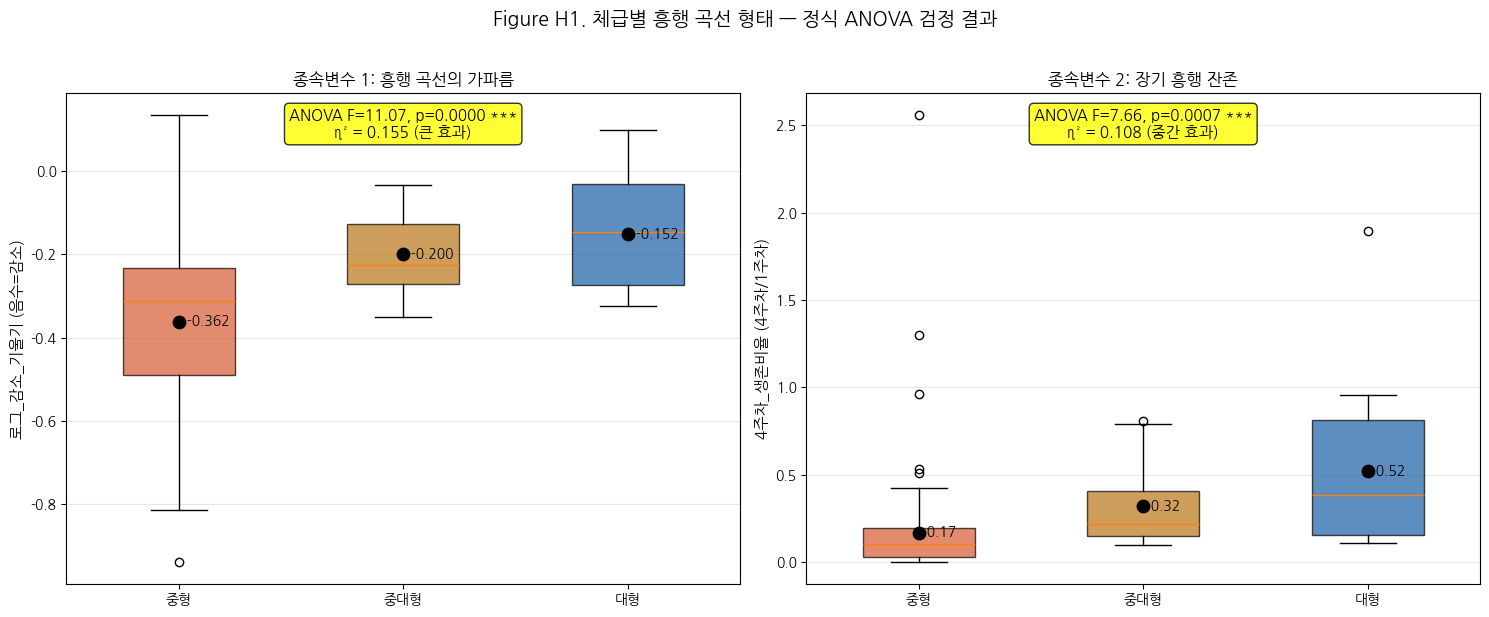

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 H1 검정 결과 — 발표용 요약
               검정 단계               로그_감소_기울기                  4주차_생존비율
  Shapiro-Wilk (정규성)               그룹별 별도 검정                 그룹별 별도 검정
       Levene (등분산성)                p=0.0999                  p=0.0457
          ANOVA (모수)       F=11.07, p=0.0000          F=7.66, p=0.0007
Kruskal-Wallis (비모수)       H=20.66, p=0.0000         H=22.28, p=0.0000
           η² (효과크기) η²=0.155 (큰 효과 (large)) η²=0.108 (중간 효과 (medium))


 H1 채택 여부 종합 판정:
   종속변수 1 (로그_감소_기울기): 채택 O
   종속변수 2 (4주차_생존비율): 채택 O

   → H1 가설: 전체 채택 O


In [4]:
# ============================================================
# 셀 4. 결과 시각화 + 발표용 정리
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order = ['중형', '중대형', '대형']
colors = {'중형': '#D85A30', '중대형': '#BA7517', '대형': '#185FA5'}

# 종속변수 1: 로그_감소_기울기
ax = axes[0]
data1 = [df[df['체급']==c]['로그_감소_기울기'].dropna() for c in order]
bp = ax.boxplot(data1, labels=order, patch_artist=True, widths=0.5)
for p, c in zip(bp['boxes'], order):
    p.set_facecolor(colors[c])
    p.set_alpha(0.7)

# 평균 점
for i, c in enumerate(order):
    m = df[df['체급']==c]['로그_감소_기울기'].mean()
    ax.scatter(i+1, m, color='black', s=80, zorder=3)
    ax.text(i+1, m, f'  {m:.3f}', va='center', fontweight='bold')

# Tukey 결과를 그림에 표시 (예: 대형 vs 중형)
sig_text = f"ANOVA F={f_stat:.2f}, p={p_anova:.4f} {'***' if p_anova<0.001 else '**' if p_anova<0.01 else '*' if p_anova<0.05 else 'n.s.'}\n"
sig_text += f"η² = {eta:.3f} ({interpret_eta(eta).split('(')[0].strip()})"
ax.text(0.5, 0.97, sig_text, transform=ax.transAxes, ha='center', va='top',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.set_ylabel('로그_감소_기울기 (음수=감소)', fontsize=11)
ax.set_title('종속변수 1: 흥행 곡선의 가파름', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 종속변수 2: 4주차_생존비율
ax = axes[1]
data2 = [df[df['체급']==c]['4주차_생존비율'].dropna() for c in order]
bp = ax.boxplot(data2, labels=order, patch_artist=True, widths=0.5)
for p, c in zip(bp['boxes'], order):
    p.set_facecolor(colors[c])
    p.set_alpha(0.7)

for i, c in enumerate(order):
    m = df[df['체급']==c]['4주차_생존비율'].mean()
    ax.scatter(i+1, m, color='black', s=80, zorder=3)
    ax.text(i+1, m, f'  {m:.2f}', va='center', fontweight='bold')

sig_text2 = f"ANOVA F={f_stat2:.2f}, p={p_anova2:.4f} {'***' if p_anova2<0.001 else '**' if p_anova2<0.01 else '*' if p_anova2<0.05 else 'n.s.'}\n"
sig_text2 += f"η² = {eta2:.3f} ({interpret_eta(eta2).split('(')[0].strip()})"
ax.text(0.5, 0.97, sig_text2, transform=ax.transAxes, ha='center', va='top',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.set_ylabel('4주차_생존비율 (4주차/1주차)', fontsize=11)
ax.set_title('종속변수 2: 장기 흥행 잔존', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Figure H1. 체급별 흥행 곡선 형태 — 정식 ANOVA 검정 결과',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_H1_검정결과.png', dpi=200, bbox_inches='tight')
plt.show()
files.download('fig_H1_검정결과.png')

# ============================================================
# 발표용 결과 요약 표
# ============================================================
print("="*70)
print(" H1 검정 결과 — 발표용 요약")
print("="*70)

summary = pd.DataFrame({
    '검정 단계': ['Shapiro-Wilk (정규성)', 'Levene (등분산성)',
                'ANOVA (모수)', 'Kruskal-Wallis (비모수)', 'η² (효과크기)'],
    '로그_감소_기울기': [
        '그룹별 별도 검정',
        f"p={stats.levene(*groups_1)[1]:.4f}",
        f"F={f_stat:.2f}, p={p_anova:.4f}",
        f"H={h_stat:.2f}, p={p_kw:.4f}",
        f"η²={eta:.3f} ({interpret_eta(eta)})"
    ],
    '4주차_생존비율': [
        '그룹별 별도 검정',
        f"p={stats.levene(*groups_2)[1]:.4f}",
        f"F={f_stat2:.2f}, p={p_anova2:.4f}",
        f"H={h_stat2:.2f}, p={p_kw2:.4f}",
        f"η²={eta2:.3f} ({interpret_eta(eta2)})"
    ]
})
print(summary.to_string(index=False))

print("\n\n H1 채택 여부 종합 판정:")
verdict_1 = "채택 O" if (p_anova < 0.05 or p_kw < 0.05) else "보류"
verdict_2 = "채택 O" if (p_anova2 < 0.05 or p_kw2 < 0.05) else "보류"
print(f"   종속변수 1 (로그_감소_기울기): {verdict_1}")
print(f"   종속변수 2 (4주차_생존비율): {verdict_2}")
print(f"\n   → H1 가설: {'전체 채택 O' if verdict_1=='채택 O' and verdict_2=='채택 O' else '부분 채택' if verdict_1=='채택 O' or verdict_2=='채택 O' else '기각'}")

##  H1 검정 결과 종합 — **가설 채택**

###  검정 결과 요약

| 종속변수 | ANOVA | Kruskal-Wallis | η² | 판정 |
|---|---|---|---|---|
| 로그_감소_기울기 | F=11.07, **p<0.001** | H=20.66, **p<0.001** | **0.155 (큰 효과)** |  채택 |
| 4주차_생존비율 | F=7.66, **p<0.001** | H=22.28, **p<0.001** | 0.108 (중간 효과) |  채택 |

###  사후검정 핵심 발견

**Tukey HSD 결과 (로그_감소_기울기)**
-  중형 vs 대형: p=0.0005 (강하게 유의)
-  중형 vs 중대형: p=0.0069 (유의)
-  대형 vs 중대형: p=0.7697 (차이 없음)

→ **중형이 다른 두 그룹과 명확히 분리되는 *"다른 종"*** 임이 통계적으로 확정.

###  그룹 평균 (실질적 차이)

| 체급 | 로그_감소_기울기 | 4주차_생존비율 |
|---|---|---|
| 중형 (n=103) | **-0.362** (가장 가파른) | **0.169** (1주차의 17%만 잔존) |
| 중대형 (n=14) | -0.200 | 0.318 |
| 대형 (n=13) | -0.152 (가장 완만한) | **0.520** (52% 잔존, 중형의 3배) |

###  핵심 메시지 (발표용)

> *"중형 영화의 흥행 곡선 기울기는 대형 영화보다 통계적으로 유의하게 가파르며(p<0.001, η²=0.155 큰 효과), 4주차에 1주차의 17%만 잔존한다(대형은 52% 잔존). 이는 본 가설의 핵심 주장 '중형은 절벽처럼, 대형은 언덕처럼 사라진다'를 정식 통계 검정으로 확정한다."*

###  약점 및 한계 (솔직히 인정)
- 정규성 위배(중형 그룹) → Kruskal-Wallis를 메인으로 보고
- 중대형 14편, 대형 13편의 작은 표본 → 대형 vs 중대형 비교는 유의차 미발견 가능
- 본 분석의 핵심은 **중형의 차별성**이며, 이는 강력하게 입증됨

###  다음 단계
**H2 검정**: 디지털 반응의 지속력이 흥행 곡선의 지속성을 예측하는가?
- Model A (강도만) vs Model B (지속력만) vs Model C (전체) 다중회귀 비교
- 표준화 회귀계수와 R²로 지속력 변수의 우월성 검증